# Objectif du notebook 

Date de création : 12/01/2026

L'objectif du notebook est d'estimer la position associée à chacune des émissions de la source. Cette étape est nécessaire à la résolution du problème des moindres carrés pour l'inversion des positions des OBS. 

In [25]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [26]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")


In [27]:
sys.path.append(project_root)
from publication.publication_figure import PubFigure, color



# Chargement des temps d'émissions de la source pointés par Timothée M. 

In [28]:
fname = "emissions_source_12012026.xlsx"
fpath = os.path.join(root_groix_metadata, fname)

df_emission_src = pd.read_excel(fpath, sheet_name="Sheet1")

In [29]:
df_emission_src

,Date,Time UTC (non synchro),Point,Source,Longueur filée (m),Hydro distance (m),Signal,Frequency min (Hz),Frequency max (Hz),Duration (s),Nrepeat,Trepeat (s),Vc carte (V),Gain ampli,File,Initial samples,Initial timestamp UTC (synchro),Comment
0,2025-10-14,08:50:04,5,trailed,14,1.70,sinus,600,600,1,10,4,1.0,5,channelA_2025-10-14_08-50-04.wav,"[19272847, 19528847, 19784847, 20040847, 20296...",NaN,not seen on DAS
1,2025-10-14,08:50:04,5,trailed,14,1.70,chirp,100,1000,5,5,10,1.0,5,channelA_2025-10-14_08-50-04.wav,"[49962471, 50602471, 51242471, 51882471, 52522...",NaN,not seen on DAS
2,2025-10-14,08:50:04,5,trailed,14,1.70,chirp,100,1000,5,10,10,1.0,5,channelA_2025-10-14_08-50-04.wav,"[65466315, 66159101, 66857251, 67575906, 68308...",NaN,"not seen on DAS, warning repetitions not regular"
3,2025-10-14,09:21:08,5,trailed,14,1.70,sinus,600,600,5,10,10,2.0,5,channelA_2025-10-14_09-21-08.wav,"[25536251, 26176251, 26816251, 27456251, 28096...",NaN,NaN
4,2025-10-14,09:21:08,5,trailed,14,1.70,sinus,615,615,5,10,10,4.0,5,channelA_2025-10-14_09-21-08.wav,"[81033224, 81673224, 82313224, 82953224, 83593...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,2025-10-16,14:27:20,1S,fixed,8,1.35,sinus,625,625,5,10,10,4.0,5,channelA_2025-10-16_13-38-03.wav,"[187486816, 188126816, 188766816, 189406816, 1...",NaN,NaN
165,2025-10-16,14:29:04,1S,fixed,8,1.35,sinus,225,225,5,10,10,4.0,5,channelA_2025-10-16_13-38-03.wav,"[194092678, 194732678, 195372678, 196012678, 1...",NaN,NaN
166,2025-10-16,14:30:51,1S,fixed,8,1.35,sinus,125,125,5,10,10,4.0,5,channelA_2025-10-16_13-38-03.wav,"[200991168, 201631168, 202271168, 202911168, 2...",NaN,NaN
167,2025-10-16,14:33:19,1S,fixed,8,1.35,chirp,80,1000,5,10,10,4.0,5,channelA_2025-10-16_13-38-03.wav,"[210334594, 210974594, 211614594, 212254594, 2...",NaN,NaN


In [30]:
# # Form a datetime series from the Date and Time UTC columns --> Old version : first columns does not match the file start time 
# date = df_emission_src["Date"]
# time = df_emission_src["Time UTC (non synchro)"]
# # Datetime serie from date and time
# start_datetime = pd.to_datetime(date.astype(str) + " " + time.astype(str), format="%Y-%m-%d %H:%M:%S")

# Get start datetime from filename
datetime_str = df_emission_src["File"].str.split("_")
date_str = datetime_str.str[1]
time_str = datetime_str.str[2].str.split(".").str[0]
start_datetime = pd.to_datetime(date_str + " " + time_str, format="%Y-%m-%d %H-%M-%S")

# Store in the dataframe
df_emission_src["Datetime"] = start_datetime

In [31]:
start_datetime

0     2025-10-14 08:50:04
1     2025-10-14 08:50:04
2     2025-10-14 08:50:04
3     2025-10-14 09:21:08
4     2025-10-14 09:21:08
              ...        
164   2025-10-16 13:38:03
165   2025-10-16 13:38:03
166   2025-10-16 13:38:03
167   2025-10-16 13:38:03
168   2025-10-16 13:38:03
Name: File, Length: 169, dtype: datetime64[ns]

In [32]:
usefull_props = df_emission_src.columns.tolist()[2:-4]  # Exclude first two and last four columns
# usefull_props.remove("Nrepeat")  # Remove Nrepeat
usefull_props.extend(["Datetime"])  # Add Datetime

usefull_data = {prop: [] for prop in usefull_props}
usefull_data["Start sample"] = []
usefull_data["Sequence_id"] = []

# Loop over each line in the emission source dataframe
for idx in df_emission_src.index:
    line = df_emission_src.loc[idx]

    # Get number of single emissions
    apriori_n_single_emissions = line["Nrepeat"]

    # Store initial samples
    init_samp = line["Initial samples"]
    if isinstance(init_samp, str):
        init_samp = init_samp.split("[")[1].split("]")[0] # Remove opening and closing bracket 
        init_samp = [int(s.strip()) for s in init_samp.split(",")]      # Transform into int list
        # Update number of single emissions
        n_single_emissions = len(init_samp)     # Number of detected emissions

        # if len(init_samp) != n_single_emissions:
        #     print(idx, len(init_samp), n_single_emissions)
    elif isinstance(init_samp, float) and np.isnan(init_samp):
        # print(idx, line)
        init_samp = [np.nan] * apriori_n_single_emissions       # If the line is empty we use apriori number of emissions
    else:
        print(f"Error reading line {idx}")
        break

    # Store all usefull informations
    for prop in usefull_props:
        usefull_data[prop].extend([line[prop]] * n_single_emissions)

    # Add sequence id = each series of emissions = one line in the original dataframe
    usefull_data["Sequence_id"].extend([idx] * n_single_emissions)

    # Add emission initial samples
    usefull_data["Start sample"].extend(
        init_samp
    )


# print(init_samp)

props_dtype = {
    "Point": str,
    "Source": str,
    "Signal": str,
    "File": str,
    "Longueur filée (m)": str,  # Line with "ascending to 2m"
    "Hydro distance (m)": np.float32,
    "Frequency min (Hz)": np.float32,
    "Frequency max (Hz)": np.float32,
    "Duration (s)": np.float32,
    "Trepeat (s)": np.float32,
    "Nrepeat": int,
    "Vc carte (V)": np.float32,
    "Gain ampli": np.float32,
}

# Convert each property to the correct dtype
for prop in usefull_data.keys():
    usefull_data[prop] = pd.Series(usefull_data[prop], dtype=props_dtype.get(prop, object))

# Create final dataframe
df = pd.DataFrame(usefull_data)
# Convert Datetime back to datetime
df["Datetime"] = pd.to_datetime(df["Datetime"])
# Rename Datetime column for clarity
df = df.rename(columns={"Datetime": "File start datetime"})

# Drop lines with nan in Start sample
df = df.dropna(subset=["Start sample"]).reset_index(drop=True)

In [33]:
# Convert Start sample into UTC time
fs = 64000 # D'après le rapport de campagne 
Ts = 1 / fs

start_delta_time = df["Start sample"] * Ts  # in seconds
start_time_utc = df["File start datetime"] + pd.to_timedelta(start_delta_time, unit="s")

In [34]:
df["Emission datetime"] = start_time_utc

# Correct offset # TODO update with actual measured offset
# t_hydro_source_offset = 27
# df["Emission datetime"] = df["Emission datetime"] + pd.Timedelta(t_hydro_source_offset, "s")

In [35]:
# df_subset = df[["Sequence_id", "File start datetime", "Emission datetime", "Start sample"]]
df_subset = df
df_subset = df_subset.loc[df_subset["Sequence_id"] == 42]
print(df_subset)
print(start_delta_time[df_subset.index])

    Point Source Longueur filée (m)  Hydro distance (m) Signal  \
360     2  fixed                  5                 1.3  chirp   
361     2  fixed                  5                 1.3  chirp   
362     2  fixed                  5                 1.3  chirp   
363     2  fixed                  5                 1.3  chirp   
364     2  fixed                  5                 1.3  chirp   
365     2  fixed                  5                 1.3  chirp   
366     2  fixed                  5                 1.3  chirp   
367     2  fixed                  5                 1.3  chirp   
368     2  fixed                  5                 1.3  chirp   
369     2  fixed                  5                 1.3  chirp   

     Frequency min (Hz)  Frequency max (Hz)  Duration (s)  Nrepeat  \
360                80.0              1000.0           5.0       10   
361                80.0              1000.0           5.0       10   
362                80.0              1000.0           5.0      

In [36]:
# Reorganize a bit for clarity : Emission datetime -> first column, Sequence_id -> second column
cols = df.columns.tolist()
cols_new_order = {
    "Emission datetime": 0,
    "Sequence_id": 1,
}
for col in cols_new_order.keys():
    cols.remove(col)
    cols.insert(cols_new_order[col], col)
df = df[cols]


# Association des émissions à la position de la source 

In [37]:
# Load datasets
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))
ds_ais = xr.open_dataset(os.path.join(data_folder, "ais.nc"))
ds_bathy = xr.open_dataset(os.path.join(data_folder, "bathy.nc"))

In [38]:
# First approach : Nearest neighbor in time for GPS
gps_emission_time = ds_gps.sel(time=df["Emission datetime"].values, method="nearest")
# Add GPS info to the dataframe
df["Emission latitude GPS"] = gps_emission_time["lat"].values
df["Emission longitude GPS"] = gps_emission_time["lon"].values
df["Emission E GPS"] = gps_emission_time["e"].values
df["Emission N GPS"] = gps_emission_time["n"].values
df["Emission U GPS"] = gps_emission_time["u"].values

In [39]:
# First approach : Nearest neighbor in time for GPS
mmsi_jules = 226916000
ds_ais = ds_ais.sel(mmsi=mmsi_jules)
ais_emission_time = ds_ais.sel(time=df["Emission datetime"].values, method="nearest")
# Add GPS info to the dataframe
df["Emission latitude AIS"] = ais_emission_time["lat"].values
df["Emission longitude AIS"] = ais_emission_time["lon"].values
df["Emission E AIS"] = ais_emission_time["e"].values
df["Emission N AIS"] = ais_emission_time["n"].values
df["Emission U AIS"] = ais_emission_time["u"].values

In [40]:
df

,Emission datetime,Sequence_id,Point,Source,Longueur filée (m),Hydro distance (m),Signal,Frequency min (Hz),Frequency max (Hz),Duration (s),...,Emission latitude GPS,Emission longitude GPS,Emission E GPS,Emission N GPS,Emission U GPS,Emission latitude AIS,Emission longitude AIS,Emission E AIS,Emission N AIS,Emission U AIS
0,2025-10-14 08:55:05.138234375,0,5,trailed,14,1.70,sinus,600.0,600.0,1.0,...,47.664747,-3.426608,2946.669679,-484.353455,29.597345,47.664825,-3.426578,2948.893452,-475.568716,29.596981
1,2025-10-14 08:55:09.138234375,0,5,trailed,14,1.70,sinus,600.0,600.0,1.0,...,47.664747,-3.426608,2946.669679,-484.353455,29.597345,47.664825,-3.426578,2948.893452,-475.568716,29.596981
2,2025-10-14 08:55:13.138234375,0,5,trailed,14,1.70,sinus,600.0,600.0,1.0,...,47.664747,-3.426608,2946.669679,-484.353455,29.597345,47.664825,-3.426578,2948.893452,-475.568716,29.596981
3,2025-10-14 08:55:17.138234375,0,5,trailed,14,1.70,sinus,600.0,600.0,1.0,...,47.664791,-3.426691,2940.433210,-479.427410,29.600590,47.664906,-3.426775,2934.111381,-466.542424,29.604453
4,2025-10-14 08:55:21.138234375,0,5,trailed,14,1.70,sinus,600.0,600.0,1.0,...,47.664791,-3.426691,2940.433210,-479.427410,29.600590,47.664906,-3.426775,2934.111381,-466.542424,29.604453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2707,2025-10-16 14:47:04.083187500,168,1S,fixed,8,1.35,chirp,80.0,1000.0,1.0,...,47.661837,-3.476190,-777.413863,-808.589761,30.196572,47.661854,-3.476392,-792.555501,-806.813865,30.194937
2708,2025-10-16 14:47:06.083187500,168,1S,fixed,8,1.35,chirp,80.0,1000.0,1.0,...,47.661815,-3.476270,-783.423168,-811.023708,30.195528,47.661831,-3.476454,-797.265345,-809.092522,30.194062
2709,2025-10-16 14:47:08.083187500,168,1S,fixed,8,1.35,chirp,80.0,1000.0,1.0,...,47.661815,-3.476270,-783.423168,-811.023708,30.195528,47.661831,-3.476454,-797.265345,-809.092522,30.194062
2710,2025-10-16 14:47:10.083187500,168,1S,fixed,8,1.35,chirp,80.0,1000.0,1.0,...,47.661815,-3.476270,-783.423168,-811.023708,30.195528,47.661831,-3.476454,-797.265345,-809.092522,30.194062


Text(0, 0.5, 'Latitude')

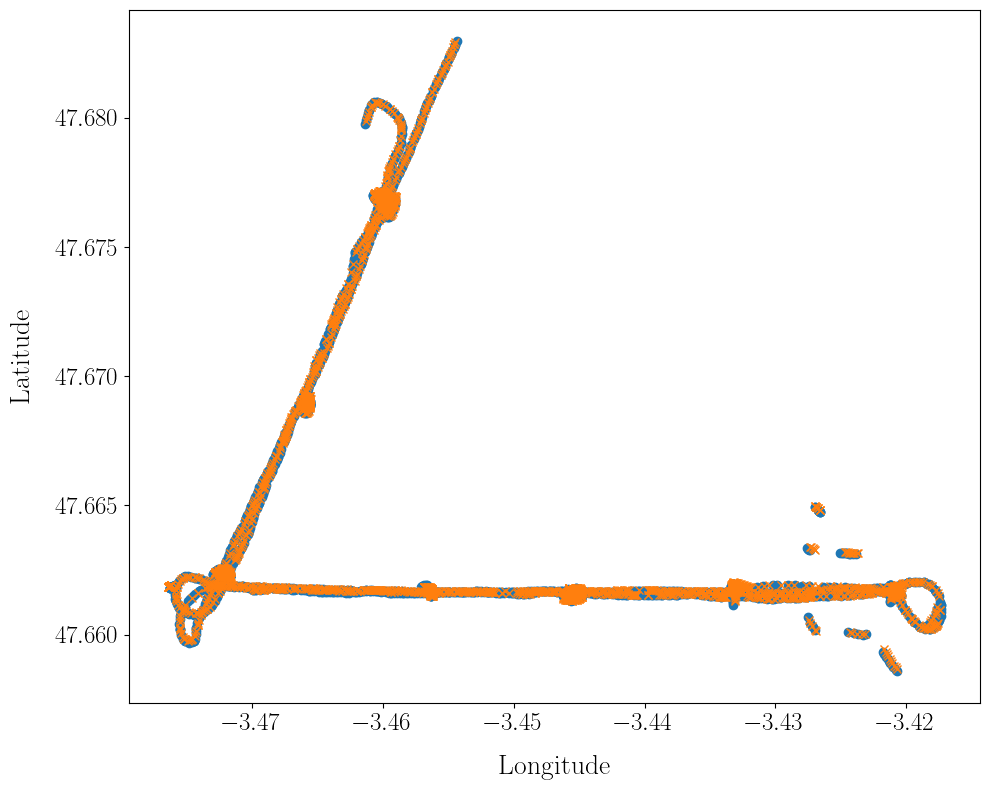

In [41]:
# Plot 
plt.figure(figsize=(10, 8))
plt.plot(df["Emission longitude GPS"], df["Emission latitude GPS"], 'o', label="GPS Emission positions")
plt.plot(df["Emission longitude AIS"], df["Emission latitude AIS"], 'x', label="AIS Emission positions")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

In [42]:
# Interp coords

# Third approach : Interpolation of ENU coords GPS
t0 = ds_gps.time.values[0]
gps_linear_time = (ds_gps.time - t0).values / np.timedelta64(1, "s")     # Linear time from start 
emission_linear_time = (df["Emission datetime"] - t0) / np.timedelta64(
    1, "s"
)  # Linear time from start
gps_emission_time_interp_e = np.interp(
    emission_linear_time.values, gps_linear_time, ds_gps.e.values
)
gps_emission_time_interp_n = np.interp(
    emission_linear_time.values, gps_linear_time, ds_gps.n.values
)
gps_emission_time_interp_u = np.interp(
    emission_linear_time.values, gps_linear_time, ds_gps.u.values
)
# Add GPS info to the dataframe
df["Emission interpolated E GPS"] = gps_emission_time_interp_e
df["Emission interpolated N GPS"] = gps_emission_time_interp_n
df["Emission interpolated U GPS"] = gps_emission_time_interp_u

# Forth approach : interpolation of ENU AIS
# mmsi_jules = 226916000
# ds_ais = ds_ais.sel(mmsi=mmsi_jules)

t0 = ds_ais.time.values[0]
ais_linear_time = (ds_ais.time - t0).values / np.timedelta64(
    1, "s"
)  # Linear time from start
ais_emission_time_interp_e = np.interp(
    emission_linear_time.values, ais_linear_time, ds_ais.e.values
)
ais_emission_time_interp_n = np.interp(
    emission_linear_time.values, ais_linear_time, ds_ais.n.values
)
ais_emission_time_interp_u = np.interp(
    emission_linear_time.values, ais_linear_time, ds_ais.u.values
)
# Add AIS info to the dataframe
df["Emission interpolated E AIS"] = ais_emission_time_interp_e
df["Emission interpolated N AIS"] = ais_emission_time_interp_n
df["Emission interpolated U AIS"] = ais_emission_time_interp_u

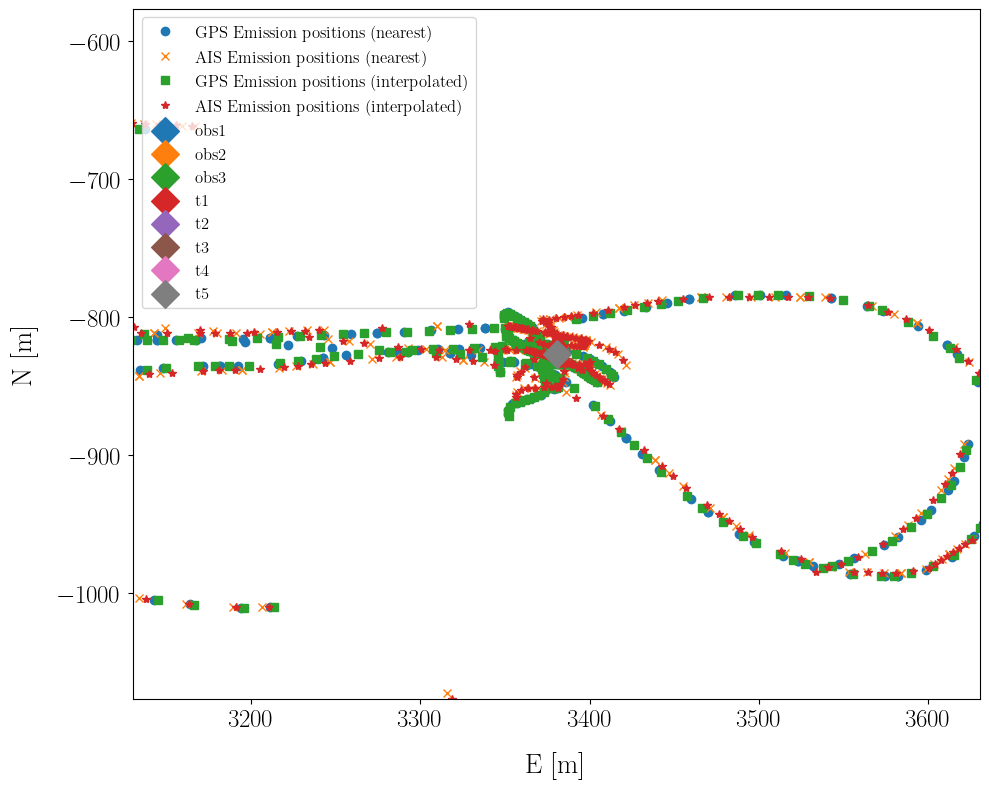

In [43]:
# Plot
plt.figure(figsize=(10, 8))
plt.plot(df["Emission E GPS"], df["Emission N GPS"], 'o', label="GPS Emission positions (nearest)")
plt.plot(df["Emission E AIS"], df["Emission N AIS"], 'x', label="AIS Emission positions (nearest)")
plt.plot(
    df["Emission interpolated E GPS"],
    df["Emission interpolated N GPS"],
    "s",
    label="GPS Emission positions (interpolated)",
)
plt.plot(
    df["Emission interpolated E AIS"],
    df["Emission interpolated N AIS"],
    "*",
    label="AIS Emission positions (interpolated)",
)
plt.xlabel("E [m]")
plt.ylabel("N [m]")

keys = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]
for k in keys:
    e = ds_gps.attrs[f"{k}_e_apriori"]
    n = ds_gps.attrs[f"{k}_n_apriori"]
    plt.scatter(
        e,
        n,
        marker="D",
        label=k,
        zorder=10,
        s=200,
    )

# ZOOM on one position
de = 500
dn = 500
src_pos_id = "t5"
plt.xlim(
    ds_gps.attrs[f"{src_pos_id}_e_apriori"] - de / 2,
    ds_gps.attrs[f"{src_pos_id}_e_apriori"] + de / 2,
)
plt.ylim(
    ds_gps.attrs[f"{src_pos_id}_n_apriori"] - dn / 2,
    ds_gps.attrs[f"{src_pos_id}_n_apriori"] + dn / 2,
)


plt.legend()

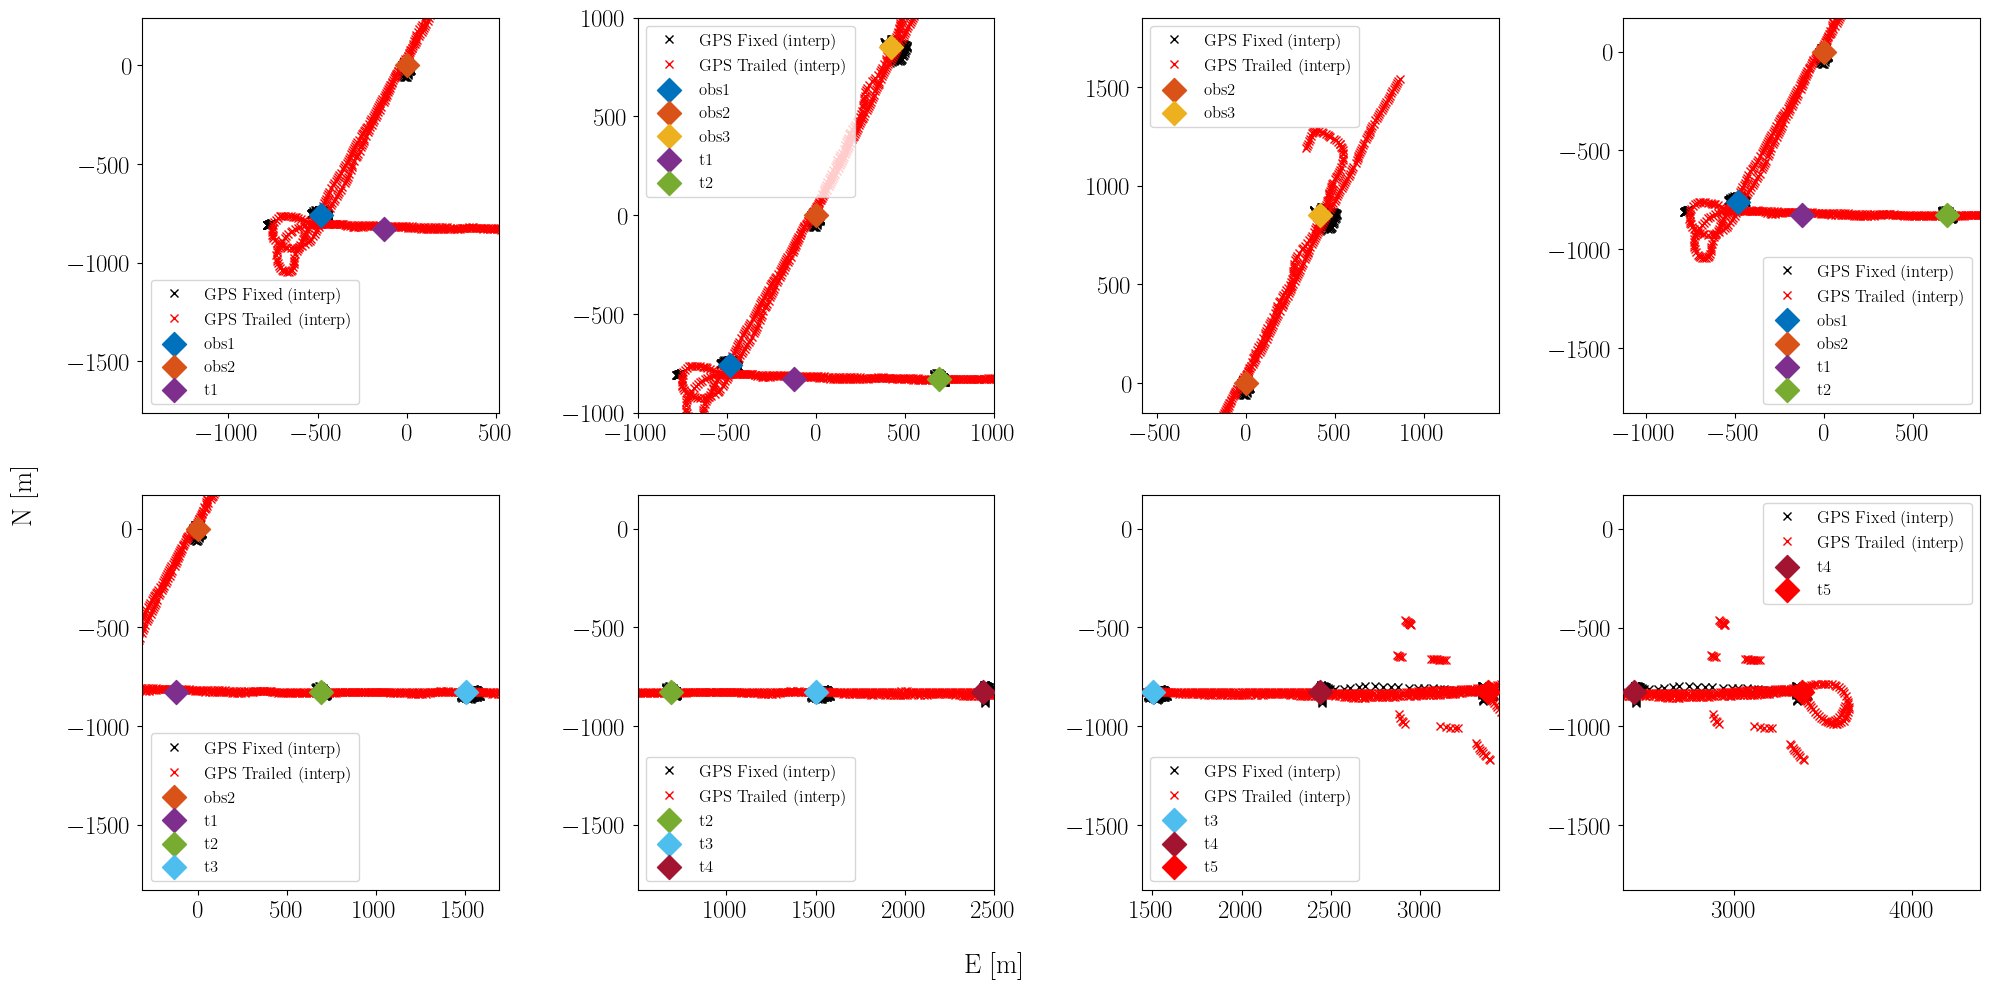

In [44]:
# Plot
pfig = PubFigure(ticks_fontsize=18, label_fontsize=20, legend_fontsize=12)
de = 2000
dn = 2000

# day = datetime(2025, 10, 14)
# df_sel = df[df["Emission datetime"] == day]
pos_of_interest = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]


fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(20, 10), sharex=False, sharey=False)
for ipos, pos in enumerate(pos_of_interest):
    i = ipos // 4
    j = ipos % 4
    ax = axs[i, j]

    # Choose color base on the type of emission (fixed or trailed)
    mask_trailed = df["Source"].str.fullmatch("trailed")
    mask_fixed = df["Source"].str.fullmatch("fixed")
    ax.plot(
        df["Emission interpolated E GPS"][mask_fixed],
        df["Emission interpolated N GPS"][mask_fixed],
        "x",
        label="GPS Fixed (interp)",
        color="k",
    )
    ax.plot(
        df["Emission interpolated E GPS"][mask_trailed],
        df["Emission interpolated N GPS"][mask_trailed],
        "x",
        label="GPS Trailed (interp)",
        color="r",
    )

    e_pos = ds_gps.attrs[f"{pos}_e_apriori"]
    n_pos = ds_gps.attrs[f"{pos}_n_apriori"]
    for ik, k in enumerate(pos_of_interest):
        e_pos_k = ds_gps.attrs[f"{k}_e_apriori"]
        n_pos_k = ds_gps.attrs[f"{k}_n_apriori"]
        if np.abs(e_pos_k - e_pos) <= de/2 and np.abs(n_pos_k - n_pos) < dn/2:
            # print(f"Plotting {k} in pos {pos}: {e_pos_k}, {n_pos_k}")
            ax.scatter(
                e_pos_k,
                n_pos_k,
                marker="D",
                label=k,
                zorder=10,
                s=150,
                color=color(ik),
            )
    ax.set_xlim([e_pos-de/2, e_pos+de/2])
    ax.set_ylim([n_pos-dn/2, n_pos+dn/2])

    ax.set_xlabel("")  
    ax.set_ylabel("")
    ax.legend()

fig.supxlabel("E [m]")
fig.supylabel("N [m]")

# Save figure 
fig_fpath = os.path.join(img_folder, "emission", "emission_positions.png")
plt.savefig(fig_fpath, dpi=300)

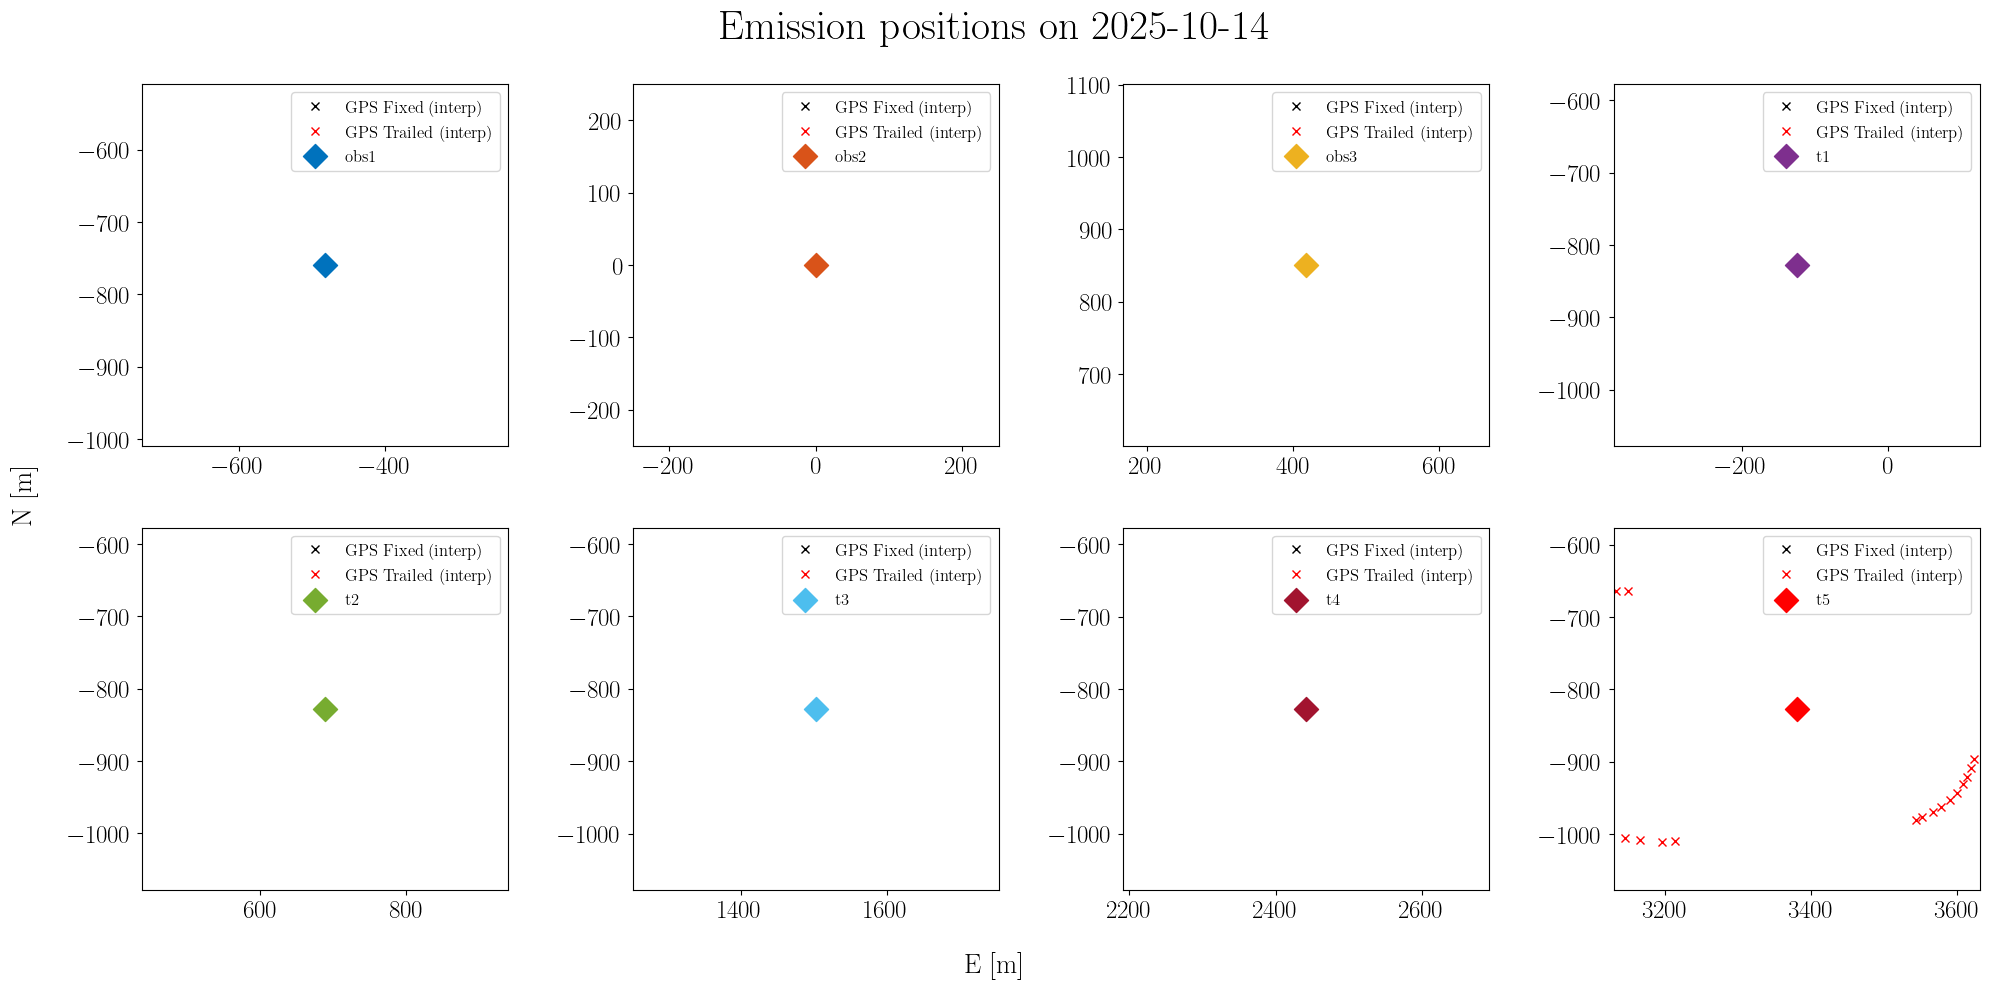

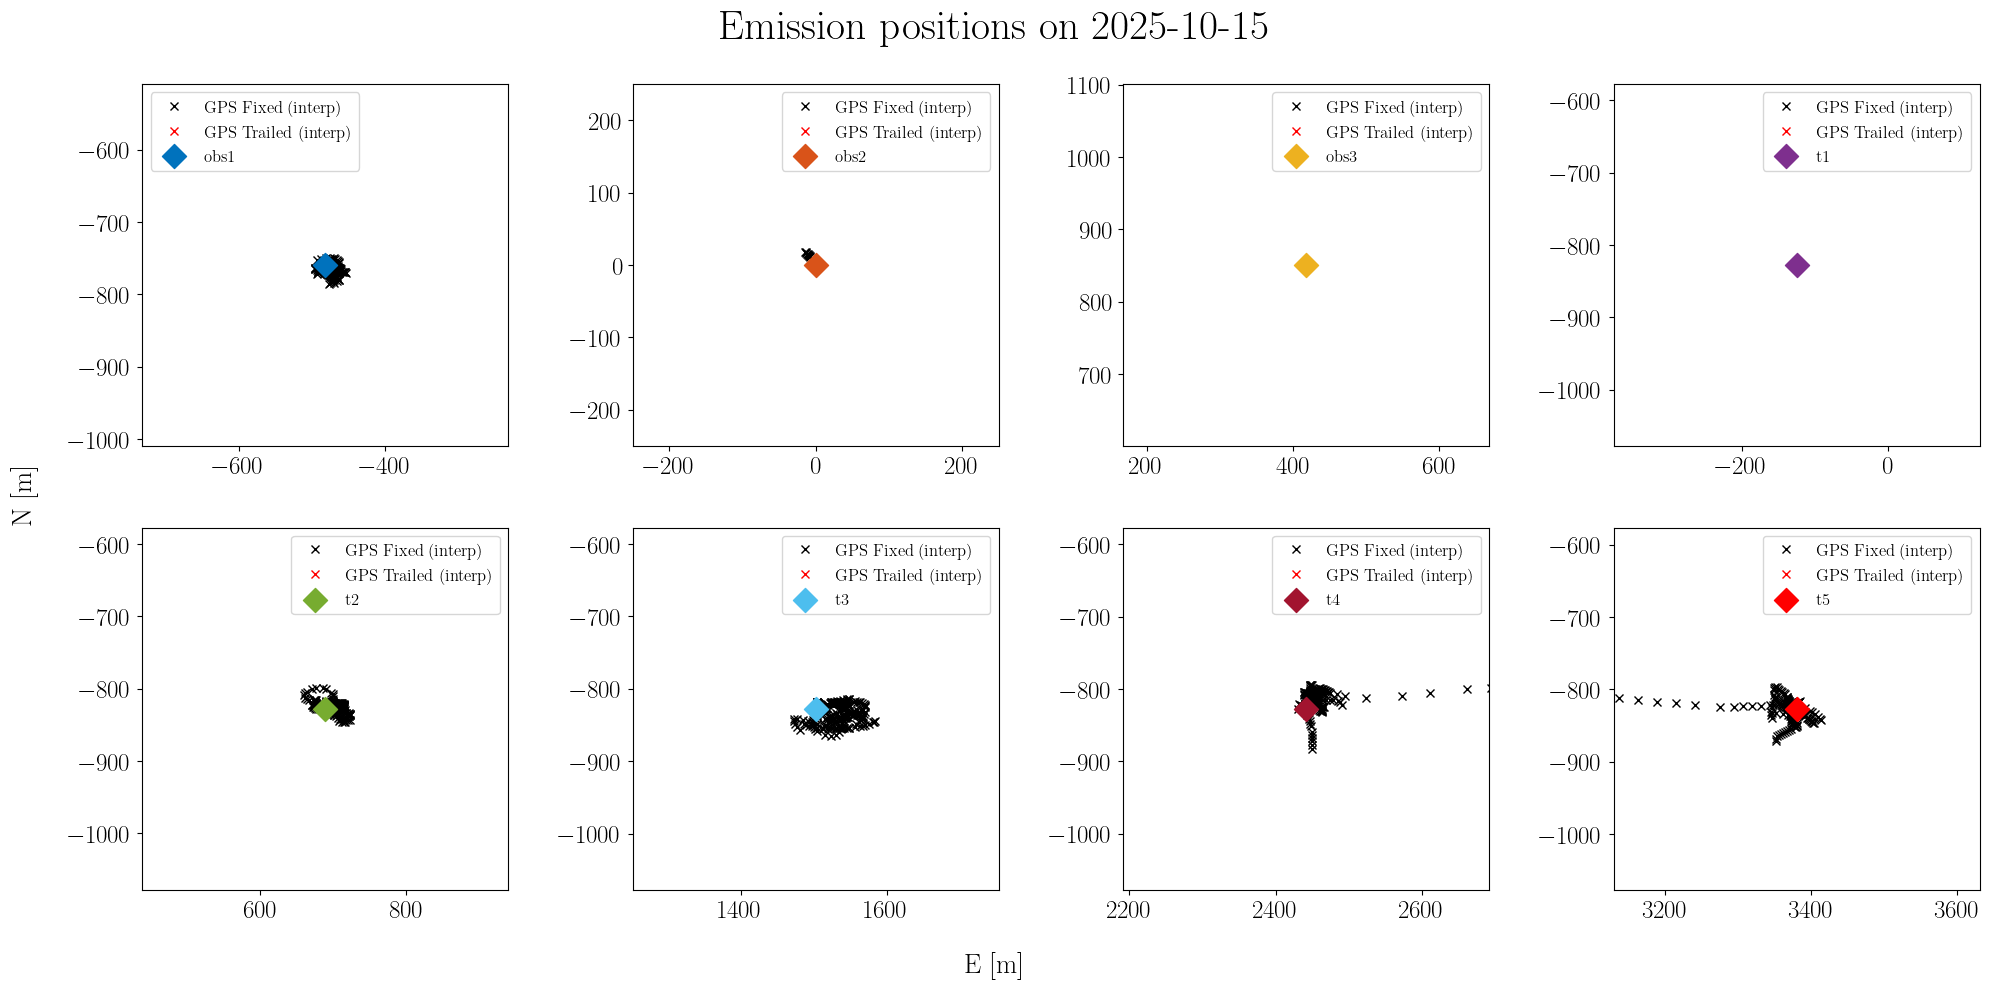

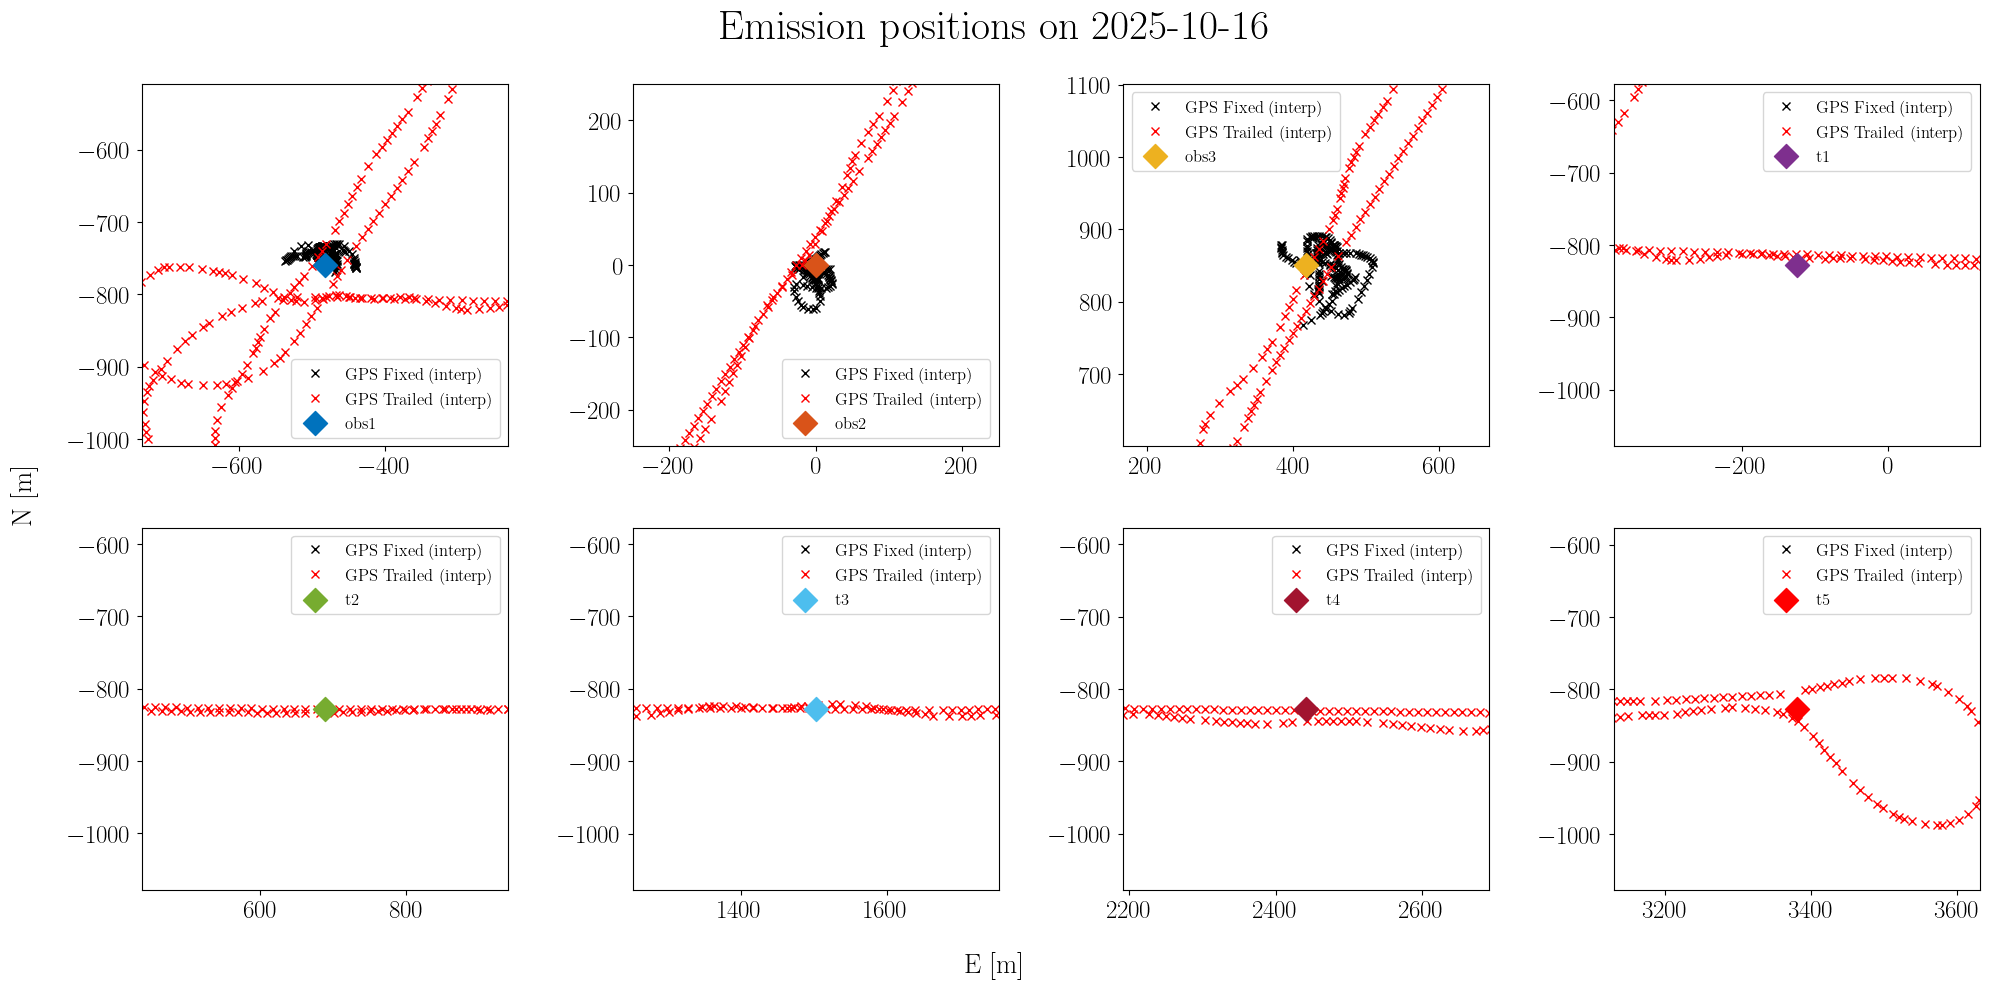

In [45]:
# Analyse each day serapately

# Plot
pfig = PubFigure(ticks_fontsize=18, label_fontsize=20, legend_fontsize=12)
de = 500
dn = 500

pos_of_interest = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]

days = df["Emission datetime"].dt.date.unique()
for day in days:

    df_sel = df[df["Emission datetime"].dt.date == day]

    fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(20, 10), sharex=False, sharey=False)
    for ipos, pos in enumerate(pos_of_interest):
        i = ipos // 4
        j = ipos % 4
        ax = axs[i, j]

        # Choose color base on the type of emission (fixed or trailed)
        mask_trailed = df["Source"].str.fullmatch("trailed")
        mask_fixed = df["Source"].str.fullmatch("fixed")
        ax.plot(
            df_sel["Emission interpolated E GPS"][mask_fixed],
            df_sel["Emission interpolated N GPS"][mask_fixed],
            "x",
            label="GPS Fixed (interp)",
            color="k",
        )
        ax.plot(
            df_sel["Emission interpolated E GPS"][mask_trailed],
            df_sel["Emission interpolated N GPS"][mask_trailed],
            "x",
            label="GPS Trailed (interp)",
            color="r",
        )

        e_pos = ds_gps.attrs[f"{pos}_e_apriori"]
        n_pos = ds_gps.attrs[f"{pos}_n_apriori"]
        for ik, k in enumerate(pos_of_interest):
            e_pos_k = ds_gps.attrs[f"{k}_e_apriori"]
            n_pos_k = ds_gps.attrs[f"{k}_n_apriori"]
            if np.abs(e_pos_k - e_pos) <= de/2 and np.abs(n_pos_k - n_pos) < dn/2:
                # print(f"Plotting {k} in pos {pos}: {e_pos_k}, {n_pos_k}")
                ax.scatter(
                    e_pos_k,
                    n_pos_k,
                    marker="D",
                    label=k,
                    zorder=10,
                    s=150,
                    color=color(ik),
                )
        ax.set_xlim([e_pos-de/2, e_pos+de/2])
        ax.set_ylim([n_pos-dn/2, n_pos+dn/2])

        ax.set_xlabel("")  
        ax.set_ylabel("")
        ax.legend()

    fig.supxlabel("E [m]")
    fig.supylabel("N [m]")

    fig.suptitle(f"Emission positions on {day.strftime('%Y-%m-%d')}")

    # Save figure
    fig_fpath = os.path.join(
        img_folder, "emission", f"emission_positions_{day.strftime('%Y_%m_%d')}.png"
    )
    plt.savefig(fig_fpath, dpi=300)

In [46]:
# Save data
fpath = os.path.join(data_folder, "source_emissions_processed.csv")
df.to_csv(fpath, index=False)

In [47]:
df.dtypes

Emission datetime              datetime64[ns]
Sequence_id                            object
Point                                  object
Source                                 object
Longueur filée (m)                     object
Hydro distance (m)                    float32
Signal                                 object
Frequency min (Hz)                    float32
Frequency max (Hz)                    float32
Duration (s)                          float32
Nrepeat                                 int32
Trepeat (s)                           float32
Vc carte (V)                          float32
Gain ampli                            float32
File                                   object
File start datetime            datetime64[ns]
Start sample                           object
Emission latitude GPS                 float64
Emission longitude GPS                float64
Emission E GPS                        float64
Emission N GPS                        float64
Emission U GPS                    

In [48]:
df_dtypes = pd.DataFrame(df.dtypes, columns=["dtype"]).reset_index()
fpath = os.path.join(data_folder, "source_emissions_processed_dtypes.csv")
df_dtypes.to_csv(fpath, index=False)